In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from helpers import *
np.random.seed(42)
tf.random.set_seed(42)

In [2]:
DATASET_DIR = "../planetsdataset"

In [3]:
IMG_SIZE = (64, 64)
BATCH_SIZE = 32

In [4]:
train_dataset, valid_dataset, test_dataset, class_names = load_datasets(DATASET_DIR, IMG_SIZE, BATCH_SIZE)
num_classes = len(class_names)

Found 2430 files belonging to 12 classes.
Found 666 files belonging to 12 classes.
Found 341 files belonging to 12 classes.


In [5]:
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.prefetch(buffer_size=AUTOTUNE)
valid_dataset = valid_dataset.prefetch(buffer_size=AUTOTUNE)
test_dataset = test_dataset.prefetch(buffer_size=AUTOTUNE)

In [6]:
num_classes = len(class_names)

#3 convolution + max pooling blocks
model = models.Sequential([
    layers.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3)),

    layers.Rescaling(1.0 / 255),

    layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 rescaling (Rescaling)       (None, 64, 64, 3)         0         
                                                                 
 conv2d (Conv2D)             (None, 64, 64, 32)        896       
                                                                 
 max_pooling2d (MaxPooling2  (None, 32, 32, 32)        0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 32, 32, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 16, 16, 64)        0         
 g2D)                                                            
                                                                 
 conv2d_2 (Conv2D)           (None, 16, 16, 128)       7

In [7]:
early_stopping = callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

In [8]:
history = model.fit(
    train_dataset,
    validation_data=valid_dataset,
    epochs=20,
    callbacks=[early_stopping]
)

Epoch 1/20
54/76 [====================>.........] - ETA: 3s - loss: 1.7135 - accuracy: 0.4190

2026-04-17 22:59:22.587249: W tensorflow/core/lib/png/png_io.cc:88] PNG warning: iCCP: known incorrect sRGB profile


76/76 [==============================] - 12s 137ms/step - loss: 1.5188 - accuracy: 0.4807 - val_loss: 0.8531 - val_accuracy: 0.7793
Epoch 2/20
54/76 [====================>.........] - ETA: 2s - loss: 0.7611 - accuracy: 0.7529

2026-04-17 22:59:33.816390: W tensorflow/core/lib/png/png_io.cc:88] PNG warning: iCCP: known incorrect sRGB profile


76/76 [==============================] - 11s 134ms/step - loss: 0.7311 - accuracy: 0.7654 - val_loss: 0.5687 - val_accuracy: 0.8003
Epoch 3/20
54/76 [====================>.........] - ETA: 2s - loss: 0.5466 - accuracy: 0.8339

...

76/76 [==============================] - 11s 133ms/step - loss: 0.1390 - accuracy: 0.9576 - val_loss: 0.4058 - val_accuracy: 0.9084
Epoch 10/20
54/76 [====================>.........] - ETA: 2s - loss: 0.1253 - accuracy: 0.9595

2026-04-17 23:01:00.714737: W tensorflow/core/lib/png/png_io.cc:88] PNG warning: iCCP: known incorrect sRGB profile


76/76 [==============================] - 11s 126ms/step - loss: 0.1380 - accuracy: 0.9535 - val_loss: 0.3798 - val_accuracy: 0.9024
Epoch 11/20
54/76 [====================>.........] - ETA: 2s - loss: 0.1277 - accuracy: 0.9549

2026-04-17 23:01:11.521219: W tensorflow/core/lib/png/png_io.cc:88] PNG warning: iCCP: known incorrect sRGB profile


76/76 [==============================] - 11s 132ms/step - loss: 0.1272 - accuracy: 0.9568 - val_loss: 0.4347 - val_accuracy: 0.8934


In [9]:
test_loss, test_acc = model.evaluate(test_dataset)
print("Test loss:", test_loss)
print("Test accuracy:", test_acc)

11/11 [==============================] - 1s 29ms/step - loss: 0.2402 - accuracy: 0.9355
Test loss: 0.24016904830932617
Test accuracy: 0.9354838728904724


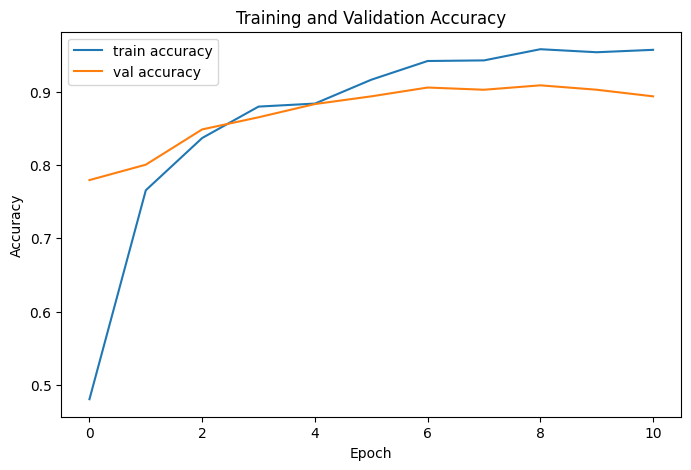

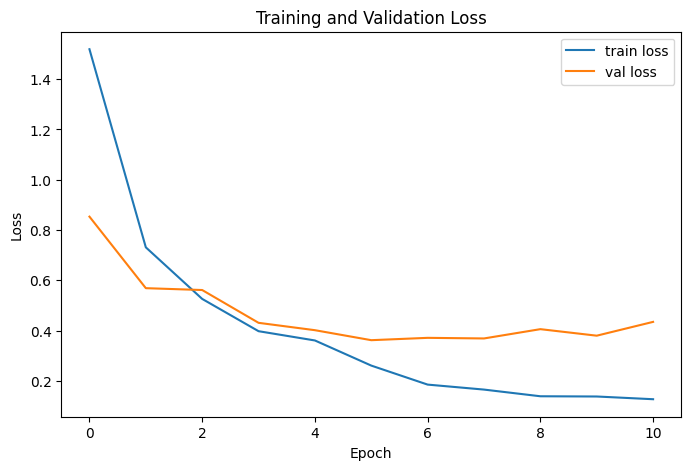

In [10]:
plot_history(history)

In [ ]:

y_pred_probs = model.predict(test_dataset)

# convert probabilities to predicted class index
y_pred = np.argmax(y_pred_probs, axis=1)

# get true class labels
y_true = np.concatenate([y for x, y in test_dataset], axis=0)

# class names in the same order as training
class_names = list(train_dataset.class_names)

# confusion matrix
cm = confusion_matrix(y_true, y_pred)

# display it
fig, ax = plt.subplots(figsize=(10, 10))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, xticks_rotation=45, cmap="Blues", colorbar=False)
plt.show()